## EXPLORATORY DATA ANALYSIS ON A DATASET

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Tasks:
### 1.	Data Cleaning and Preparation:


##### ●	Load the dataset into a data frame or equivalent data structure

In [32]:
#load a dataset()
cardio_data=pd.read_csv('Cardiotocographic.csv')
#diplay dataset 
cardio_data.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [33]:
# check null value and dataset details
cardio_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


##### ●	Handle missing values appropriately (e.g., imputation, deletion).

In [34]:
#check missing value and total missing value
cardio_data.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [35]:
#fill missing values
cardio_data.fillna(cardio_data.median(), inplace=True)

In [36]:
#check once
cardio_data.isnull().sum()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

##### ●	Identify and correct any inconsistencies in data types (e.g., numerical values stored as strings).

In [37]:
#check datatypes
cardio_data.dtypes

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object

##### ●	Detect and treat outliers if necessary.

In [38]:
#get 25th quantitle
Q1 = cardio_data.quantile(0.25)
#get 75th quantitle
Q3 = cardio_data.quantile(0.75)

# Calculate IQR (spread of middle 50%)
IQR = Q3 - Q1

In [39]:
# Find outliers using 1.5 * IQR rule
outliers = ((cardio_data < (Q1 - 1.5 * IQR)) | 
            (cardio_data > (Q3 + 1.5 * IQR))).sum()

# Show number of outliers in each column
outliers

LB           10
AC           43
FM          347
UC           13
DL          125
DS          120
DP          284
ASTV         10
MSTV         80
ALTV        318
MLTV         81
Width        10
Tendency     10
NSP         559
dtype: int64

###### Outlier Detection (Excluding NSP)

In [40]:
# Remove NSP column because it is a categorical target variable
data_no_target = cardio_data.drop('NSP', axis=1)

# Calculate Q1 (25th percentile)
Q1 = data_no_target.quantile(0.25)

# Calculate Q3 (75th percentile)
Q3 = data_no_target.quantile(0.75)

# Calculate IQR (spread of middle 50% data)
IQR = Q3 - Q1

In [41]:
# Detect outliers using 1.5 * IQR rule
outliers = ((data_no_target < (Q1 - 1.5 * IQR)) |
            (data_no_target > (Q3 + 1.5 * IQR))).sum()

# Show number of outliers per feature
outliers

LB           10
AC           43
FM          347
UC           13
DL          125
DS          120
DP          284
ASTV         10
MSTV         80
ALTV        318
MLTV         81
Width        10
Tendency     10
dtype: int64

### 2.	Statistical Summary:

##### ●	Provide a statistical summary for each variable in the dataset, including measures of central tendency (mean, median) and dispersion (standard deviation, interquartile range).

In [42]:
#Descriptive Statistics
cardio_data.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.340204,0.003204,0.009894,0.004391,0.001895,0.000002,0.000173,46.995984,1.364378,10.285964,8.276147,70.395387,0.313246,1.301499
std,11.214379,0.004373,0.067540,0.003340,0.003343,0.000141,0.000836,18.813973,1.173632,21.205041,7.734851,42.720508,0.643186,0.642133
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005606,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


In [43]:
summary = cardio_data.describe().T
summary['Median'] = cardio_data.median()
summary['IQR'] = summary['75%'] - summary['25%']
summary

,count,mean,std,min,25%,50%,75%,max,Median,IQR
LB,2126.0,133.340204,11.214379,51.842487,126.000000,133.000000,140.000000,214.000000,133.000000,14.000000
AC,2126.0,0.003204,0.004373,-0.019284,0.000000,0.001634,0.005606,0.038567,0.001634,0.005606
FM,2126.0,0.009894,0.067540,-0.480634,0.000000,0.000000,0.002567,0.961268,0.000000,0.002567
UC,2126.0,0.004391,0.003340,-0.014925,0.001851,0.004484,0.006536,0.030002,0.004484,0.004685
DL,2126.0,0.001895,0.003343,-0.015393,0.000000,0.000000,0.003289,0.030769,0.000000,0.003289
DS,2126.0,0.000002,0.000141,-0.001353,0.000000,0.000000,0.000000,0.002706,0.000000,0.000000
DP,2126.0,0.000173,0.000836,-0.005348,0.000000,0.000000,0.000000,0.010695,0.000000,0.000000
ASTV,2126.0,46.995984,18.813973,-63.000000,32.000000,49.000000,61.000000,162.000000,49.000000,29.000000
MSTV,2126.0,1.364378,1.173632,-6.600000,0.700000,1.200000,1.700000,13.800000,1.200000,1.000000
ALTV,2126.0,10.285964,21.205041,-91.000000,0.000000,0.000000,11.000000,182.000000,0.000000,11.000000


##### ●	Highlight any interesting findings from this summary.

- LB (Baseline FHR) is normally distributed (mean ≈ median), indicating stable heart rate patterns.

- Deceleration features (DL, DS, DP) have median = 0, showing most cases do not exhibit decelerations.

- Fetal Movements (FM) is highly skewed, with many zero values and few extreme observations.

- Variability features (ASTV, ALTV, MLTV) show high dispersion, suggesting strong differences in heart rate variability.

- Width has a large IQR, indicating wide spread in signal measurements.

- NSP shows most cases belong to the normal fetal state, indicating slight class imbalance.

### 3.	Data Visualization:

##### ●	Create histograms or boxplots to visualize the distributions of various numerical variables.

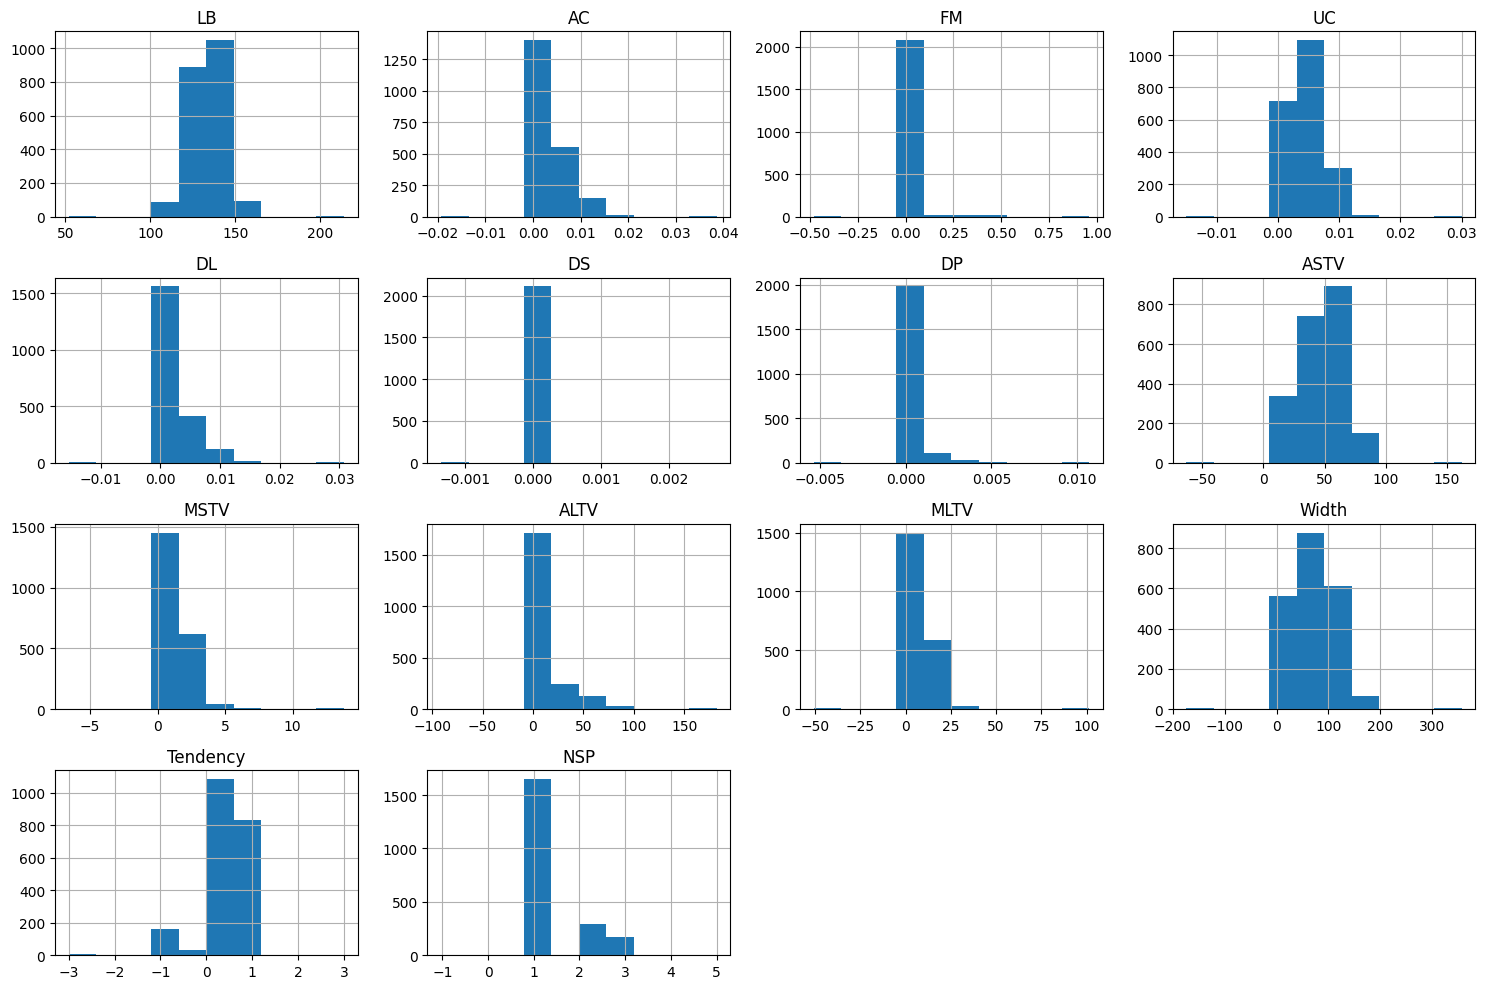

In [49]:
# Plot histograms for all numerical features
# Helps understand distribution, skewness, and spread
cardio_data.hist(figsize=(15,10))

# Adjust layout to prevent overlapping
plt.tight_layout()

# Display the plot
plt.show()

##### ●	Use bar charts or pie charts to display the frequency of categories for categorical variables.

###### Boxplot (All Features)

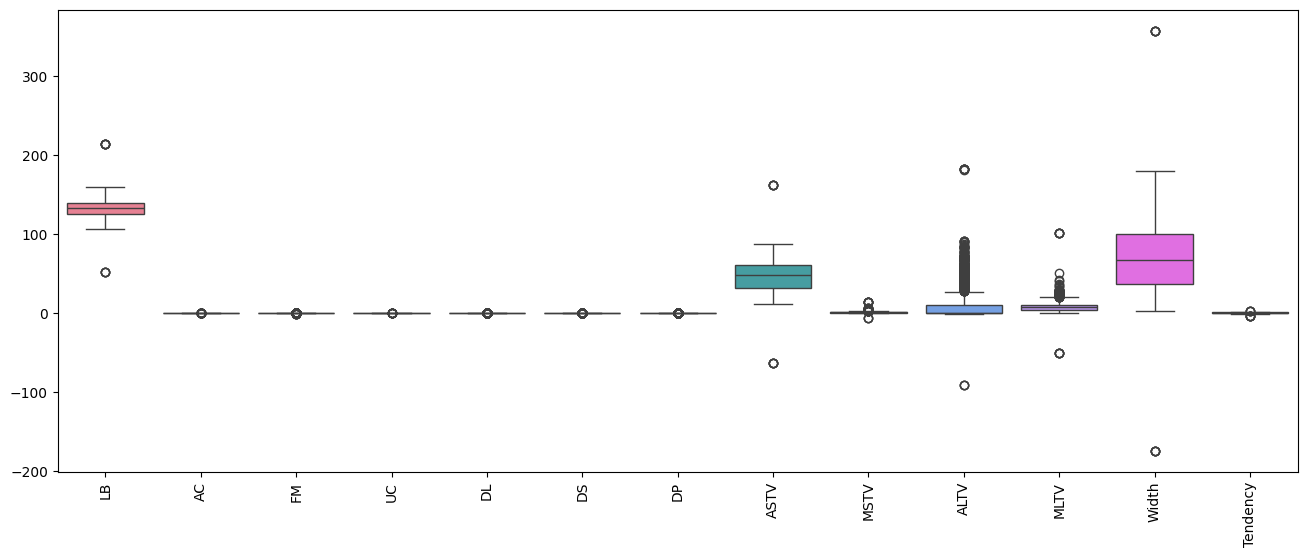

In [50]:
# Create boxplot for numerical features (excluding target variable)
# Helps detect outliers and compare dispersion
plt.figure(figsize=(16,6))
sns.boxplot(data=cardio_data.drop('NSP', axis=1))

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Display the plot
plt.show()

###### Boxplot (Important Feature Groups)

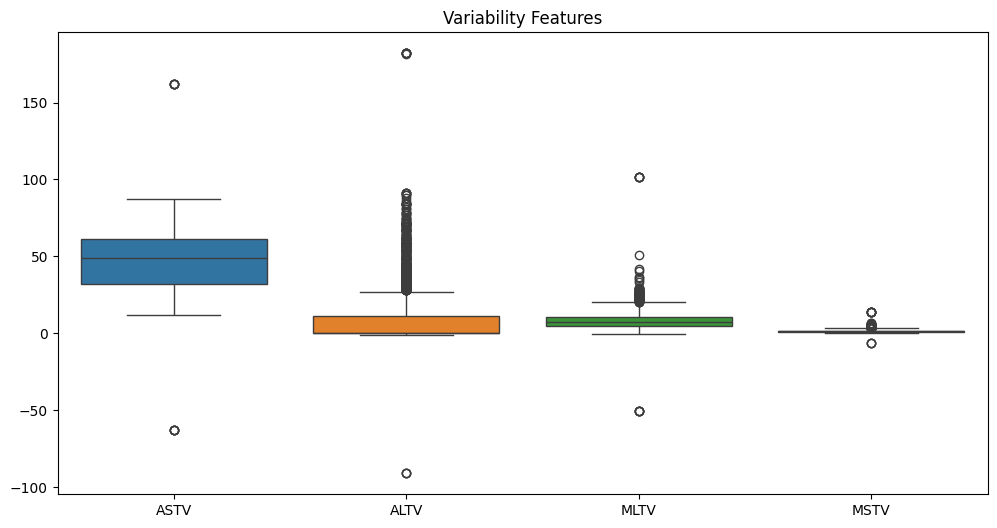

In [51]:
# Boxplot for variability features
# Shows spread and extreme values in heart rate variability
plt.figure(figsize=(12,6))
sns.boxplot(data=cardio_data[['ASTV','ALTV','MLTV','MSTV']])
plt.title("Variability Features")
plt.show()

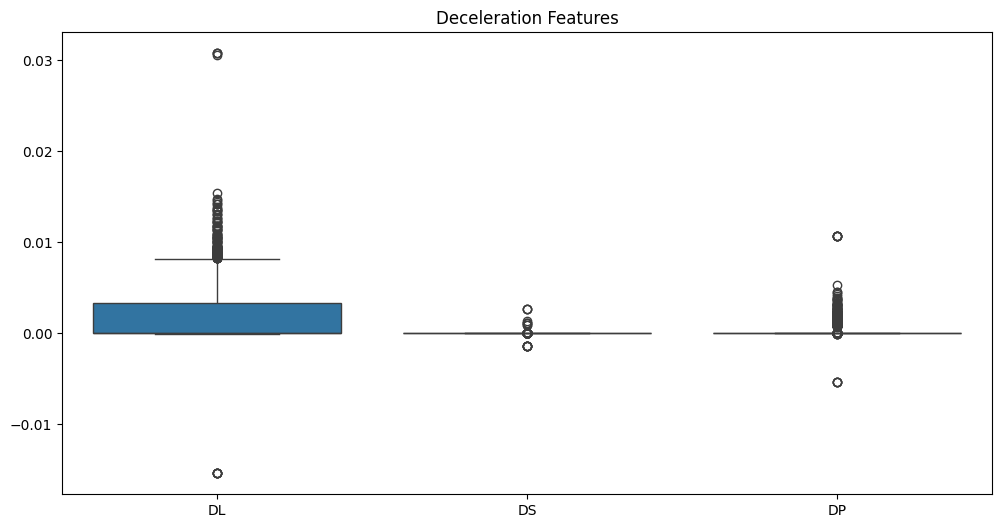

In [52]:
# Boxplot for deceleration features
# Helps analyze skewness and rare extreme cases
plt.figure(figsize=(12,6))
sns.boxplot(data=cardio_data[['DL','DS','DP']])
plt.title("Deceleration Features")
plt.show()

###### Bar Chart for NSP

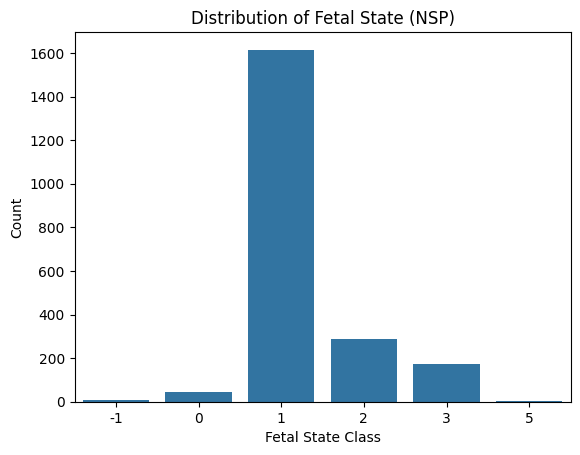

In [54]:
# Convert NSP to integer (since it represents categories 1, 2, 3)
cardio_data['NSP'] = cardio_data['NSP'].astype(int)

# Plot class distribution
sns.countplot(x='NSP', data=cardio_data)

plt.title("Distribution of Fetal State (NSP)")
plt.xlabel("Fetal State Class")
plt.ylabel("Count")
plt.show()

##### ●	Generate scatter plots or correlation heatmaps to explore relationships between pairs of variables.

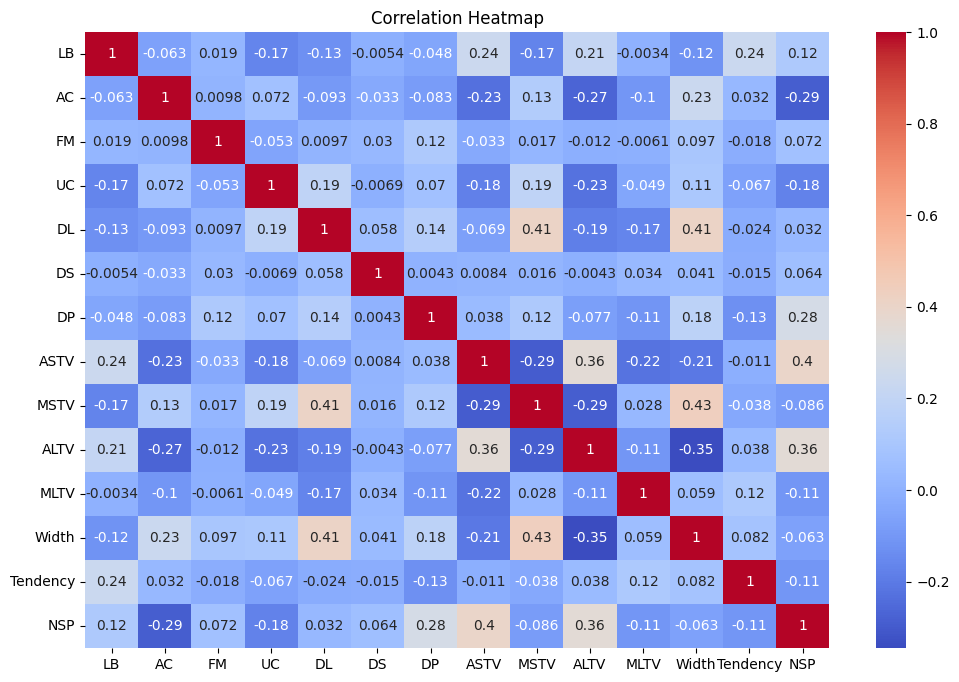

In [55]:
# Generate correlation matrix
# Helps identify relationships between variables
plt.figure(figsize=(12,8))
sns.heatmap(cardio_data.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

##### ●	Employ advanced visualization techniques like pair plots, or violin plots for deeper insights.

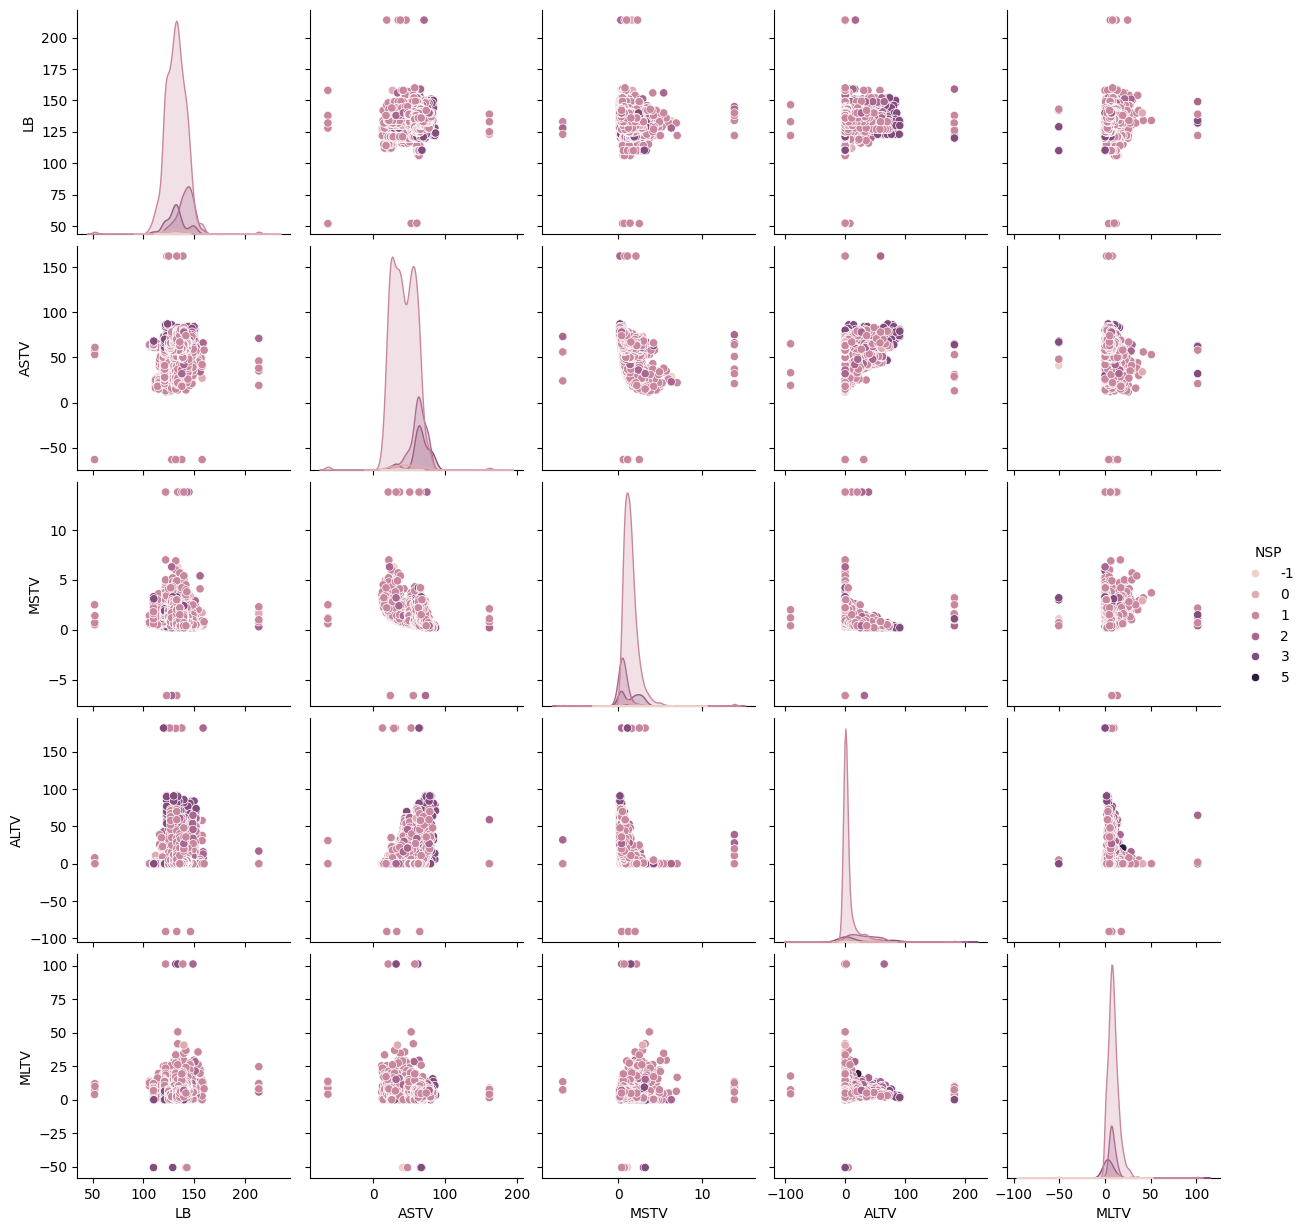

In [56]:
# Pairplot for selected important features
# Helps visualize class separation and relationships
sns.pairplot(cardio_data[['LB','ASTV','MSTV','ALTV','MLTV','NSP']], hue='NSP')

plt.show()

### 4.	Pattern Recognition and Insights:

##### ●	Identify any correlations between variables and discuss their potential implications.

> Correlation Between Variables:
- ASTV and MSTV are strongly related, which means short-term variability features move together.
- ALTV and MLTV are also closely related, showing connection in long-term variability.
- Variability features (ASTV, ALTV, MLTV) show influence on NSP (fetal state).
- Deceleration features (DL, DP) increase in some abnormal cases.

##### ●	Look for trends or patterns over time if temporal data is available.

> Observed Patterns:

- Most deceleration values are zero, meaning most fetuses do not show distress.

- High values of ALTV and ASTV are seen more in abnormal fetal conditions.

- Baseline heart rate (LB) is mostly stable and within normal range.

- Majority of NSP values are 1 (Normal), so normal cases dominate the dataset.

> Time-Based Trends:

- The dataset does not include time-related variables.

- Therefore, trend analysis over time cannot be performed.

### 5.Conclusion

##### ●	Summarize the key insights and patterns discovered through your exploratory analysis.

> Summary of Key Findings

- The dataset contains 2126 records and 14 numerical features.

- Baseline fetal heart rate is generally stable.

- Variability features show high differences across cases.

- Deceleration features are mostly zero but extreme values indicate possible fetal risk.

- Most cases belong to the normal fetal state.

##### ●	Discuss how these findings could impact decision-making or further analyses.

> How These Findings Help
 - Variability features are key indicators of fetal health.
 - Extreme values may represent abnormal conditions.
 - Class imbalance should be considered during model building.
 - The analysis supports development of a fetal health prediction model.